# 5. Clustering

Agrupar as unidades pelo desempenho nos quatro indicadores com K-Means. O agrupamento é de unidades, nunca de pessoas.

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set_theme(style='whitegrid')
SEMENTE = 20262

df = pd.read_csv('../saidas/unidades.csv')
colunas = ['ind1', 'ind2', 'ind3', 'ind4']

# K-Means usa distância, então as variáveis precisam estar na mesma escala
X = StandardScaler().fit_transform(df[colunas])

## Escolha do k

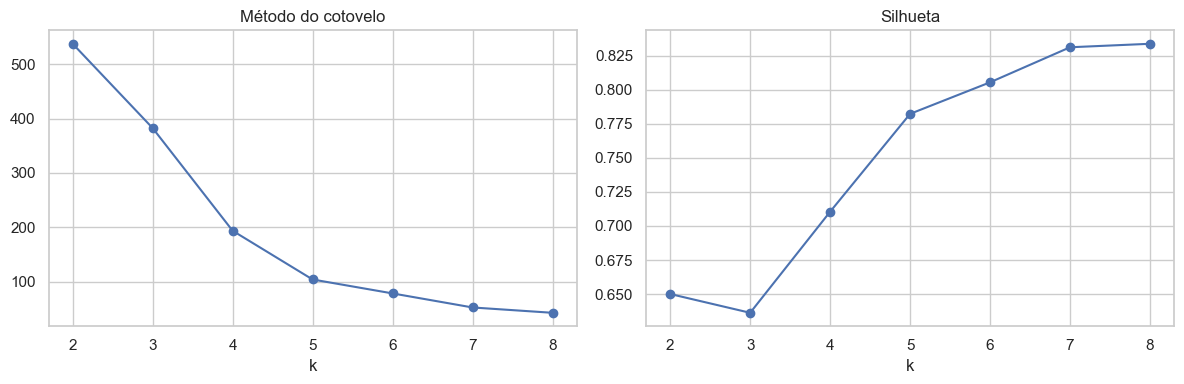

2    0.650
3    0.636
4    0.710
5    0.782
6    0.805
7    0.831
8    0.834
Name: silhueta, dtype: float64

In [2]:
inercias, silhuetas = [], []
valores_k = range(2, 9)
for k in valores_k:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=SEMENTE).fit(X)
    inercias.append(kmeans.inertia_)
    silhuetas.append(silhouette_score(X, kmeans.labels_))

fig, eixos = plt.subplots(1, 2, figsize=(12, 4))
eixos[0].plot(valores_k, inercias, marker='o')
eixos[0].set_title('Método do cotovelo')
eixos[0].set_xlabel('k')
eixos[1].plot(valores_k, silhuetas, marker='o')
eixos[1].set_title('Silhueta')
eixos[1].set_xlabel('k')
plt.tight_layout()
plt.show()

pd.Series(silhuetas, index=valores_k, name='silhueta').round(3)

A inércia cai bastante até k = 4 e depois a queda diminui. A silhueta continua subindo com k maior porque as notas andam em poucos degraus: com muitos grupos, quase cada combinação de notas vira um grupo. Ficamos com k = 4, onde está o cotovelo e os grupos ainda são fáceis de ler.

In [3]:
k = 4
kmeans = KMeans(n_clusters=k, n_init=10, random_state=SEMENTE)
df['grupo'] = kmeans.fit_predict(X) + 1
silhueta = silhouette_score(X, df['grupo'])
print('silhueta:', round(silhueta, 3))

silhueta: 0.71


## Perfil dos grupos

In [4]:
perfil = df.groupby('grupo').agg(
    unidades=('tipo', 'size'),
    tipo_mais_comum=('familia', lambda s: s.mode()[0]),
    ind1=('ind1', 'mean'), ind2=('ind2', 'mean'), ind3=('ind3', 'mean'), ind4=('ind4', 'mean'),
    geral=('geral', 'mean'),
).sort_values('geral', ascending=False)
perfil.round(3)

,unidades,tipo_mais_comum,ind1,ind2,ind3,ind4,geral
grupo,,,,,,,
2,12,MAC,0.625,0.5,3.110,0.975,1.237
3,73,USF,0.750,0.5,1.862,0.817,0.949
1,100,USF,0.490,0.5,1.849,0.815,0.893
4,5,USF,0.550,0.0,1.686,0.849,0.786


In [5]:
pd.crosstab(df['grupo'], df['familia'])

familia,CAPS,CECO,MAC,UBT,UCIS,USF
grupo,,,,,,
1,9,0,4,13,1,73
2,0,0,12,0,0,0
3,8,1,2,6,1,55
4,1,0,1,1,0,2


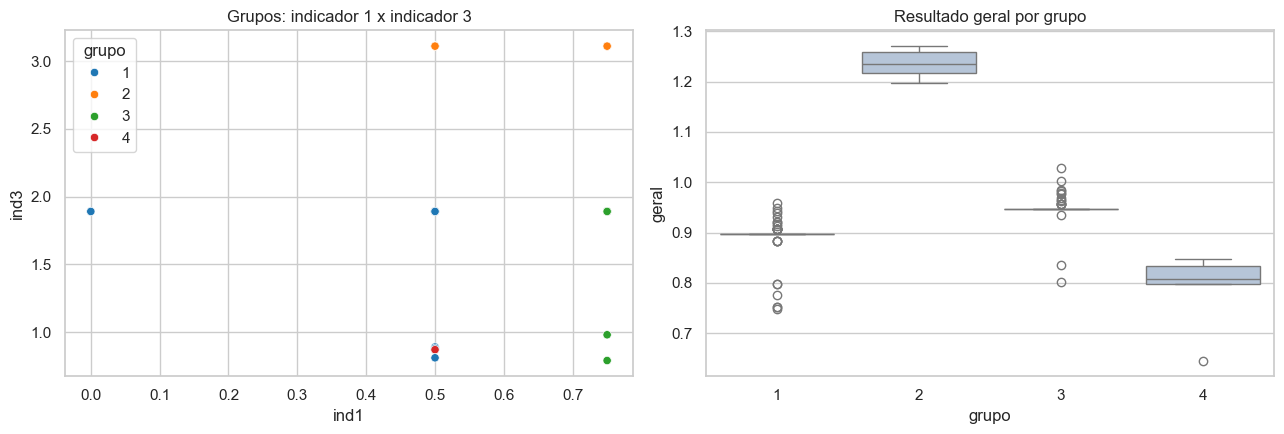

In [6]:
fig, eixos = plt.subplots(1, 2, figsize=(13, 4.5))
sns.scatterplot(data=df, x='ind1', y='ind3', hue='grupo', palette='tab10', ax=eixos[0])
eixos[0].set_title('Grupos: indicador 1 x indicador 3')
sns.boxplot(data=df, x='grupo', y='geral', ax=eixos[1], color='lightsteelblue')
eixos[1].set_title('Resultado geral por grupo')
plt.tight_layout()
plt.show()

Os grupos seguem principalmente o tipo de unidade, o que faz sentido porque cada tipo tem uma régua própria na portaria. Entre as USF, o que mais separa os grupos é o indicador 1.

In [7]:
resultado = {
    'modelo': 'clustering',
    'pergunta': 'Quais unidades têm desempenho parecido nos quatro indicadores?',
    'metodo': f'K-Means com k={k}, escolhido pelo cotovelo e pela silhueta, sobre as notas dos quatro indicadores padronizadas.',
    'metricas': {
        'silhueta': round(float(silhueta), 3),
        'k': k,
        'grupos': [
            {'nome': f"grupo {g}: maioria {linha['tipo_mais_comum']}", 'unidades': int(linha['unidades']), 'resultado_medio': round(float(linha['geral']), 3)}
            for g, linha in perfil.iterrows()
        ],
    },
    'referencia': {'nome': 'silhueta de referência', 'observacao': 'acima de 0,5 indica separação nítida'},
    'limitacao': 'Agrupa unidades, nunca pessoas. Os grupos refletem sobretudo o tipo de unidade.',
}

with open('../saidas/clustering.json', 'w', encoding='utf-8') as arquivo:
    json.dump(resultado, arquivo, ensure_ascii=False, indent=2)